In [4]:
# Cierra la sesión Spark previa, si existiera
try:
    spark.stop()
except:
    pass

# Fuerza que driver y workers usen el MISMO Python que tu kernel
import sys, os
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

# Crea Spark local y desactiva Arrow (evita choques por tipos mixtos)
from pyspark.sql import SparkSession
spark = (
    SparkSession.builder
    .appName("AccidentesGT-local")
    .master("local[*]")
    .config("spark.sql.execution.arrow.pyspark.enabled", "false")
    .getOrCreate()
)

print("Spark:", spark.version)
print("Python driver:", sys.executable)

Spark: 3.5.5
Python driver: /opt/anaconda3/envs/spark310/bin/python


In [5]:
# Cierra la sesión Spark previa, si existiera
try:
    spark.stop()
except:
    pass

# Fuerza que driver y workers usen el MISMO Python que tu kernel
import sys, os
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

# Crea Spark local y desactiva Arrow (evita choques por tipos mixtos)
from pyspark.sql import SparkSession
spark = (
    SparkSession.builder
    .appName("AccidentesGT-local")
    .master("local[*]")
    .config("spark.sql.execution.arrow.pyspark.enabled", "false")
    .getOrCreate()
)

print("Spark:", spark.version)
print("Python driver:", sys.executable)

Spark: 3.5.5
Python driver: /opt/anaconda3/envs/spark310/bin/python


----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 52298)
Traceback (most recent call last):
  File "/opt/anaconda3/envs/spark310/lib/python3.10/socketserver.py", line 316, in _handle_request_noblock
    self.process_request(request, client_address)
  File "/opt/anaconda3/envs/spark310/lib/python3.10/socketserver.py", line 347, in process_request
    self.finish_request(request, client_address)
  File "/opt/anaconda3/envs/spark310/lib/python3.10/socketserver.py", line 360, in finish_request
    self.RequestHandlerClass(request, client_address, self)
  File "/opt/anaconda3/envs/spark310/lib/python3.10/socketserver.py", line 747, in __init__
    self.handle()
  File "/opt/anaconda3/envs/spark310/lib/python3.10/site-packages/pyspark/accumulators.py", line 295, in handle
    poll(accum_updates)
  File "/opt/anaconda3/envs/spark310/lib/python3.10/site-packages/pyspark/accumulators.py", line 267, in poll
    if self.rfile in r and func

# Inciso 1

In [6]:
import pandas as pd, unicodedata, re
from pyspark.sql import functions as F

def norm_cols(cols):
    out = []
    for c in cols:
        c = "".join(ch for ch in unicodedata.normalize("NFD", str(c)) if unicodedata.category(ch) != "Mn")
        c = c.strip().lower().replace("-", "_").replace(" ", "_")
        c = re.sub(r"[^a-z0-9_]", "", c)
        out.append(c)
    return out

def read_excel_to_spark_safe(path):
    """
    Lee Excel con pandas dtype=str para evitar tipos mixtos
    y convierte a Spark. Luego castearás columnas en Spark.
    """
    pdf = pd.read_excel(path, engine="openpyxl", dtype=str)
    pdf.columns = norm_cols(pdf.columns)
    return spark.createDataFrame(pdf)

def cast_if(df, col, dtype):
    return df.withColumn(col, F.col(col).cast(dtype)) if col in df.columns else df

In [7]:
BASE = "/Users/pabloherrera/Documents/Universidad/Data Science/Lab9Spark"
path_grand = f"{BASE}/grand_dataframe.xlsx"

df_grand = read_excel_to_spark_safe(path_grand)

# Casteos suaves
df_grand = cast_if(df_grand, "anio", "int")
df_grand = cast_if(df_grand, "dia_ocu", "int")
df_grand = cast_if(df_grand, "zona_ocu", "int")
df_grand = cast_if(df_grand, "num_vehiculos_involucrados", "int")
# hora_ocu la dejamos como string

df_grand.createOrReplaceTempView("grand")

df_grand.printSchema()
df_grand.show(10, truncate=False)

root
 |-- anio: integer (nullable = true)
 |-- depto_ocu: string (nullable = true)
 |-- dia_ocu: integer (nullable = true)
 |-- fall_les: string (nullable = true)
 |-- hora_ocu: string (nullable = true)
 |-- mes_ocu: string (nullable = true)
 |-- num_vehiculos_involucrados: integer (nullable = true)
 |-- origen: string (nullable = true)
 |-- tipo_eve: string (nullable = true)
 |-- zona_ocu: integer (nullable = true)



25/10/09 20:52:27 WARN TaskSetManager: Stage 0 contains a task of very large size (1661 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

+----+---------+-------+--------+--------+-------+--------------------------+---------------------+--------+--------+
|anio|depto_ocu|dia_ocu|fall_les|hora_ocu|mes_ocu|num_vehiculos_involucrados|origen               |tipo_eve|zona_ocu|
+----+---------+-------+--------+--------+-------+--------------------------+---------------------+--------+--------+
|2013|Guatemala|1      |NaN     |5       |Enero  |NULL                      |fallecidos_lesionados|NaN     |11      |
|2013|Guatemala|1      |NaN     |5       |Enero  |NULL                      |fallecidos_lesionados|NaN     |11      |
|2013|Guatemala|1      |NaN     |5       |Enero  |NULL                      |fallecidos_lesionados|NaN     |11      |
|2013|Zacapa   |1      |NaN     |0       |Enero  |NULL                      |fallecidos_lesionados|NaN     |99      |
|2013|Zacapa   |1      |NaN     |0       |Enero  |NULL                      |fallecidos_lesionados|NaN     |99      |
|2013|Zacapa   |1      |NaN     |18      |Enero  |NULL  

In [8]:
from pyspark.sql import functions as F

# mapa meses (español -> número)
mes_map = F.create_map(
    F.lit("enero"), F.lit(1), F.lit("febrero"), F.lit(2), F.lit("marzo"), F.lit(3),
    F.lit("abril"), F.lit(4), F.lit("mayo"), F.lit(5), F.lit("junio"), F.lit(6),
    F.lit("julio"), F.lit(7), F.lit("agosto"), F.lit(8), F.lit("septiembre"), F.lit(9),
    F.lit("octubre"), F.lit(10), F.lit("noviembre"), F.lit(11), F.lit("diciembre"), F.lit(12)
)

g = df_grand

# Deriva fecha y día de semana
g = (g
     .withColumn("mes_l", F.lower(F.col("mes_ocu")))
     .withColumn("mes_num", mes_map[F.col("mes_l")].cast("int"))
     .withColumn("fecha_ocu",
                 F.to_date(F.format_string("%04d-%02d-%02d",
                                           F.col("anio"), F.col("mes_num"), F.col("dia_ocu"))))
     .withColumn("dow_en", F.date_format(F.col("fecha_ocu"), "E"))
     .withColumn(
         "dia_semana",
         F.when(F.col("dow_en").isin("Mon","Mon."),"Lunes")
          .when(F.col("dow_en").isin("Tue","Tue."),"Martes")
          .when(F.col("dow_en").isin("Wed","Wed."),"Miércoles")
          .when(F.col("dow_en").isin("Thu","Thu."),"Jueves")
          .when(F.col("dow_en").isin("Fri","Fri."),"Viernes")
          .when(F.col("dow_en").isin("Sat","Sat."),"Sábado")
          .when(F.col("dow_en").isin("Sun","Sun."),"Domingo")
     )
)

# Selección final para el análisis exploratorio
select_cols = [
    "anio","mes_ocu","dia_ocu","dia_semana","hora_ocu","zona_ocu",
    "depto_ocu","tipo_eve","num_vehiculos_involucrados","fall_les","origen"
]
df_preparado = g.select(*[c for c in select_cols if c in g.columns])
df_preparado.createOrReplaceTempView("prep")

df_preparado.printSchema()
df_preparado.show(20, truncate=False)

root
 |-- anio: integer (nullable = true)
 |-- mes_ocu: string (nullable = true)
 |-- dia_ocu: integer (nullable = true)
 |-- dia_semana: string (nullable = true)
 |-- hora_ocu: string (nullable = true)
 |-- zona_ocu: integer (nullable = true)
 |-- depto_ocu: string (nullable = true)
 |-- tipo_eve: string (nullable = true)
 |-- num_vehiculos_involucrados: integer (nullable = true)
 |-- fall_les: string (nullable = true)
 |-- origen: string (nullable = true)

+----+-------+-------+----------+--------+--------+-------------+--------+--------------------------+--------+---------------------+
|anio|mes_ocu|dia_ocu|dia_semana|hora_ocu|zona_ocu|depto_ocu    |tipo_eve|num_vehiculos_involucrados|fall_les|origen               |
+----+-------+-------+----------+--------+--------+-------------+--------+--------------------------+--------+---------------------+
|2013|Enero  |1      |Martes    |5       |11      |Guatemala    |NaN     |NULL                      |NaN     |fallecidos_lesionados|
|2013

25/10/09 20:52:38 WARN TaskSetManager: Stage 1 contains a task of very large size (1661 KiB). The maximum recommended task size is 1000 KiB.


In [9]:
out_parquet = f"{BASE}/out_parquet/preparado.parquet"
(df_preparado
 .repartition(8)
 .write.mode("overwrite")
 .parquet(out_parquet))
print("Parquet escrito en:", out_parquet)

25/10/09 20:52:55 WARN TaskSetManager: Stage 2 contains a task of very large size (1661 KiB). The maximum recommended task size is 1000 KiB.
Java HotSpot(TM) 64-Bit Server VM warning: CodeCache is full. Compiler has been disabled.
Java HotSpot(TM) 64-Bit Server VM warning: Try increasing the code cache size using -XX:ReservedCodeCacheSize=


CodeCache: size=131072Kb used=26380Kb max_used=26393Kb free=104691Kb
 bounds [0x0000000106c20000, 0x0000000108610000, 0x000000010ec20000]
 total_blobs=9601 nmethods=8686 adapters=827
 compilation: disabled (not enough contiguous free space left)


25/10/09 20:52:57 WARN MemoryManager: Total allocation exceeds 95.00% (906,992,014 bytes) of heap memory
Scaling row group sizes to 96.54% for 7 writers
25/10/09 20:52:57 WARN MemoryManager: Total allocation exceeds 95.00% (906,992,014 bytes) of heap memory
Scaling row group sizes to 84.47% for 8 writers
[Stage 4:>                                                          (0 + 8) / 8]

Parquet escrito en: /Users/pabloherrera/Documents/Universidad/Data Science/Lab9Spark/out_parquet/preparado.parquet


25/10/09 20:52:58 WARN MemoryManager: Total allocation exceeds 95.00% (906,992,014 bytes) of heap memory
Scaling row group sizes to 96.54% for 7 writers
                                                                                

# Inciso 2

In [10]:
from pyspark.sql import functions as F

BASE = "/Users/pabloherrera/Documents/Universidad/Data Science/Lab9Spark"
parquet_path = f"{BASE}/out_parquet/preparado.parquet"   # <- el que guardaste

df_preparado = spark.read.parquet(parquet_path)
df_preparado.printSchema()
df_preparado.show(5, truncate=False)

root
 |-- anio: integer (nullable = true)
 |-- mes_ocu: string (nullable = true)
 |-- dia_ocu: integer (nullable = true)
 |-- dia_semana: string (nullable = true)
 |-- hora_ocu: string (nullable = true)
 |-- zona_ocu: integer (nullable = true)
 |-- depto_ocu: string (nullable = true)
 |-- tipo_eve: string (nullable = true)
 |-- num_vehiculos_involucrados: integer (nullable = true)
 |-- fall_les: string (nullable = true)
 |-- origen: string (nullable = true)

+----+----------+-------+----------+--------+--------+-------------+--------+--------------------------+---------+---------------------+
|anio|mes_ocu   |dia_ocu|dia_semana|hora_ocu|zona_ocu|depto_ocu    |tipo_eve|num_vehiculos_involucrados|fall_les |origen               |
+----+----------+-------+----------+--------+--------+-------------+--------+--------------------------+---------+---------------------+
|2014|Septiembre|10     |Miércoles |6       |6       |Guatemala    |Colisión|NULL                      |Lesionado|fallecidos_l

In [11]:
# mapa meses español -> número
mes_map = F.create_map(
    F.lit("enero"), F.lit(1), F.lit("febrero"), F.lit(2), F.lit("marzo"), F.lit(3),
    F.lit("abril"), F.lit(4), F.lit("mayo"), F.lit(5), F.lit("junio"), F.lit(6),
    F.lit("julio"), F.lit(7), F.lit("agosto"), F.lit(8), F.lit("septiembre"), F.lit(9),
    F.lit("octubre"), F.lit(10), F.lit("noviembre"), F.lit(11), F.lit("diciembre"), F.lit(12)
)

g = df_preparado

# mes_num
g = g.withColumn("mes_num", mes_map[F.lower(F.col("mes_ocu"))].cast("int"))

# hora_num (toma el primer grupo de dígitos como hora)
g = g.withColumn(
    "hora_num",
    F.regexp_extract(F.coalesce(F.col("hora_ocu"), F.lit("")), r"(\d{1,2})", 1).cast("int")
)

# severidad (2 fallecido, 1 lesionado, 0 ignorado/NaN)
g = g.withColumn(
    "sev_score",
    F.when(F.lower(F.col("fall_les")) == "fallecido", 2)
     .when(F.lower(F.col("fall_les")) == "lesionado", 1)
     .otherwise(0)
)

# tipos numéricos suaves
g = (g
     .withColumn("anio", F.col("anio").cast("int"))
     .withColumn("dia_ocu", F.col("dia_ocu").cast("int"))
     .withColumn("zona_ocu", F.col("zona_ocu").cast("int"))
     .withColumn("num_vehiculos_involucrados", F.col("num_vehiculos_involucrados").cast("int"))
)

g.select("anio","mes_ocu","mes_num","dia_ocu","hora_ocu","hora_num",
         "zona_ocu","num_vehiculos_involucrados","fall_les","sev_score").show(10, truncate=False)

+----+----------+-------+-------+--------+--------+--------+--------------------------+---------+---------+
|anio|mes_ocu   |mes_num|dia_ocu|hora_ocu|hora_num|zona_ocu|num_vehiculos_involucrados|fall_les |sev_score|
+----+----------+-------+-------+--------+--------+--------+--------------------------+---------+---------+
|2014|Septiembre|9      |10     |6       |6       |6       |NULL                      |Lesionado|1        |
|2016|Julio     |7      |4      |10      |10      |7       |NULL                      |Lesionado|1        |
|2013|Octubre   |10     |24     |12      |12      |99      |NULL                      |NaN      |0        |
|2016|Agosto    |8      |13     |21      |21      |99      |NULL                      |Lesionado|1        |
|2013|Diciembre |12     |21     |5       |5       |1       |NULL                      |NaN      |0        |
|2015|Diciembre |12     |20     |10      |10      |1       |NULL                      |Lesionado|1        |
|2016|Junio     |6      |29 

In [14]:
from pyspark.sql import functions as F

# Las mismas features que ibas a usar:
feature_cols = ["sev_score","num_vehiculos_involucrados","zona_ocu","anio","mes_num","dia_ocu","hora_num"]

# Reporte por columna: nulos, distintos y desviación estándar
stats = []
for c in feature_cols:
    stats.append(
        g.select(
            F.lit(c).alias("col"),
            F.count(F.when(F.col(c).isNull(), 1)).alias("n_null"),
            F.count("*").alias("n_total"),
            F.countDistinct(F.col(c)).alias("n_distinct"),
            F.stddev_samp(F.col(c).cast("double")).alias("stddev")
        )
    )

report = stats[0]
for s in stats[1:]:
    report = report.unionByName(s)

report.orderBy("col").show(truncate=False)

[Stage 20:>                                                         (0 + 8) / 8]

+--------------------------+------+-------+----------+-------------------+
|col                       |n_null|n_total|n_distinct|stddev             |
+--------------------------+------+-------+----------+-------------------+
|anio                      |0     |269889 |11        |3.2030158548143897 |
|dia_ocu                   |0     |269889 |31        |8.84157074511794   |
|hora_num                  |87    |269889 |24        |6.654827399908882  |
|mes_num                   |22562 |269889 |12        |3.5232899306438505 |
|num_vehiculos_involucrados|179466|269889 |2         |0.49284719430166574|
|sev_score                 |0     |269889 |3         |0.597921653928527  |
|zona_ocu                  |0     |269889 |23        |39.12596034361179  |
+--------------------------+------+-------+----------+-------------------+



In [15]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

# Selecciona automáticamente columnas con varianza > 0 y al menos 2 valores distintos
rep = report.collect()
valid_cols = [r["col"] for r in rep if r["n_distinct"] > 1 and r["stddev"] is not None and float(r["stddev"]) > 0.0]

print("Usando columnas para correlación:", valid_cols)

# Asegura que no queden nulos en esas columnas
g_num = g
for c in valid_cols:
    g_num = g_num.filter(F.col(c).isNotNull())

# Revisa cantidad de filas disponibles
print("Filas para correlación:", g_num.count())

# Si hay menos de 2 filas, Pearson no se puede calcular
if g_num.count() < 2 or len(valid_cols) < 2:
    raise ValueError("No hay suficientes filas o columnas válidas para calcular correlación.")

assembler = VectorAssembler(inputCols=valid_cols, outputCol="features", handleInvalid="skip")
g_vec = assembler.transform(g_num).select("features")

corr_mat = Correlation.corr(g_vec, "features", "pearson").head()[0]

Usando columnas para correlación: ['sev_score', 'num_vehiculos_involucrados', 'zona_ocu', 'anio', 'mes_num', 'dia_ocu', 'hora_num']
Filas para correlación: 90391


25/10/09 20:59:11 WARN PearsonCorrelation: Pearson correlation matrix contains NaN values.


In [16]:
import numpy as np
import pandas as pd

corr_df = pd.DataFrame(np.array(corr_mat.toArray()), index=feature_cols, columns=feature_cols)
corr_df.round(3)

,sev_score,num_vehiculos_involucrados,zona_ocu,anio,mes_num,dia_ocu,hora_num
sev_score,1.0,NaN,NaN,NaN,NaN,NaN,NaN
num_vehiculos_involucrados,NaN,1.000,-0.052,0.053,0.003,-0.006,-0.028
zona_ocu,NaN,-0.052,1.000,-0.055,-0.013,0.012,0.047
anio,NaN,0.053,-0.055,1.000,-0.022,-0.003,-0.013
mes_num,NaN,0.003,-0.013,-0.022,1.000,0.030,-0.008
dia_ocu,NaN,-0.006,0.012,-0.003,0.030,1.000,0.003
hora_num,NaN,-0.028,0.047,-0.013,-0.008,0.003,1.000


# Inciso 3

In [17]:
from pyspark.sql import functions as F

# meses → número
mes_map = F.create_map(
    F.lit("enero"), F.lit(1),  F.lit("febrero"), F.lit(2),  F.lit("marzo"), F.lit(3),
    F.lit("abril"), F.lit(4),  F.lit("mayo"),    F.lit(5),  F.lit("junio"), F.lit(6),
    F.lit("julio"), F.lit(7),  F.lit("agosto"),  F.lit(8),  F.lit("septiembre"), F.lit(9),
    F.lit("octubre"),F.lit(10),F.lit("noviembre"),F.lit(11),F.lit("diciembre"),F.lit(12)
)

g = df_preparado

# mes_num
g = g.withColumn("mes_num", mes_map[F.lower(F.col("mes_ocu"))].cast("int"))

# hora_num (primer grupo de dígitos)
g = g.withColumn(
    "hora_num",
    F.regexp_extract(F.coalesce(F.col("hora_ocu"), F.lit("")), r"(\d{1,2})", 1).cast("int")
)

# indicadores de fallecido/lesionado (filas sin 'fall_les' → 0)
g = g.withColumn("fallecido_ind", F.when(F.lower(F.col("fall_les")) == "fallecido", 1).otherwise(0))
g = g.withColumn("lesionado_ind", F.when(F.lower(F.col("fall_les")) == "lesionado", 1).otherwise(0))

# castear otras columnas numéricas típicas
g = (g
     .withColumn("anio", F.col("anio").cast("int"))
     .withColumn("dia_ocu", F.col("dia_ocu").cast("int"))
     .withColumn("zona_ocu", F.col("zona_ocu").cast("int"))
     .withColumn("num_vehiculos_involucrados", F.col("num_vehiculos_involucrados").cast("int"))
)

g.select("anio","mes_num","dia_ocu","hora_num",
         "zona_ocu","num_vehiculos_involucrados",
         "fallecido_ind","lesionado_ind","tipo_eve","origen").show(10, truncate=False)

+----+-------+-------+--------+--------+--------------------------+-------------+-------------+--------+---------------------+
|anio|mes_num|dia_ocu|hora_num|zona_ocu|num_vehiculos_involucrados|fallecido_ind|lesionado_ind|tipo_eve|origen               |
+----+-------+-------+--------+--------+--------------------------+-------------+-------------+--------+---------------------+
|2014|9      |10     |6       |6       |NULL                      |0            |1            |Colisión|fallecidos_lesionados|
|2016|7      |4      |10      |7       |NULL                      |0            |1            |Colisión|fallecidos_lesionados|
|2013|10     |24     |12      |99      |NULL                      |0            |0            |NaN     |fallecidos_lesionados|
|2016|8      |13     |21      |99      |NULL                      |0            |1            |Choque  |fallecidos_lesionados|
|2013|12     |21     |5       |1       |NULL                      |0            |0            |NaN     |falleci

In [24]:
# === PCA + extracción de PC1/PC2 vía RDD (Spark 3.1, sin UDF) ===
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.linalg import Vector
from pyspark.sql import functions as F

# 1) features
pca_features = [
    "hora_num",
    "num_vehiculos_involucrados",
    "lesionado_ind",
    "fallecido_ind",
    "zona_ocu",
    "anio",
    "mes_num",
    "dia_ocu",
]

# 2) filtra nulos
g_num = g
for c in pca_features:
    g_num = g_num.filter(F.col(c).isNotNull())

# 3) assembler → scaler → pca
va = VectorAssembler(inputCols=pca_features, outputCol="features", handleInvalid="skip")
vdf = va.transform(g_num)

scaler = StandardScaler(inputCol="features", outputCol="scaled", withStd=True, withMean=True)
sdf = scaler.fit(vdf).transform(vdf)

pca = PCA(k=2, inputCol="scaled", outputCol="pcaFeatures")
pca_model = pca.fit(sdf)
pca_df = pca_model.transform(sdf)
print("Explained variance (PC1, PC2):", pca_model.explainedVariance.toArray())

# 4) EXTRAER PC1/PC2 convirtiendo el vector a tupla de floats vía RDD
def vec_first_two(v: Vector):
    arr = v.toArray()
    return float(arr[0]), float(arr[1])

pca_plot = (pca_df
    .select("pcaFeatures","tipo_eve","origen")
    .rdd.map(lambda r: (*vec_first_two(r.pcaFeatures), r.tipo_eve, r.origen))
    .toDF(["PC1","PC2","tipo_eve","origen"])
)

pca_plot.show(10, truncate=False)

Explained variance (PC1, PC2): [0.18804972 0.17248696]
+-------------------+-------------------+---------+----------------------+
|PC1                |PC2                |tipo_eve |origen                |
+-------------------+-------------------+---------+----------------------+
|-0.4606163078716319|0.18411839711745615|Colisión |vehiculos_involucrados|
|-1.4467799993896642|0.27757579065955634|Vuelco   |vehiculos_involucrados|
|-0.8380287717494311|0.5585198513997136 |Vuelco   |vehiculos_involucrados|
|-0.6878922045740046|0.457467438774649  |Caída    |vehiculos_involucrados|
|1.111959055681553  |-0.5853234590815282|Colisión |vehiculos_involucrados|
|-0.7929212687487849|-0.6211463305369034|Choque   |vehiculos_involucrados|
|-2.124729524220951 |0.2168043017041913 |Atropello|vehiculos_involucrados|
|-0.2037848793986145|0.7390300434971282 |Atropello|vehiculos_involucrados|
|-0.7813073335556715|0.4565500977815249 |Colisión |vehiculos_involucrados|
|0.3126382592410357 |-1.3728098373371092|Coli

Text(0, 0.5, 'PC2')

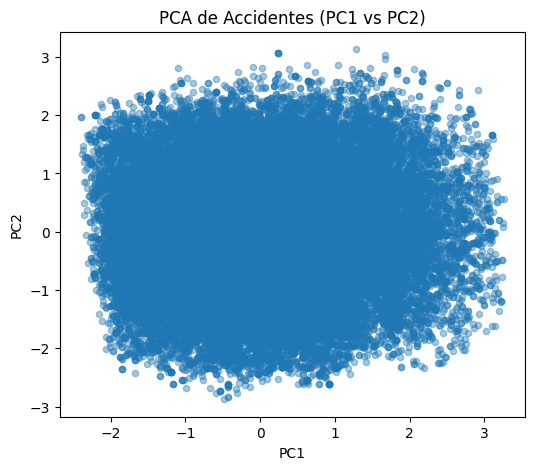

In [28]:
import matplotlib.pyplot as plt
# --- pasar a pandas (con muestreo opcional para no reventar la RAM) ---
pdf = pca_plot.toPandas()
if len(pdf) > 50000:
    pdf = pdf.sample(n=50000, random_state=42)

# --- gráfico simple ---
ax = pdf.plot(kind="scatter", x="PC1", y="PC2", alpha=0.4, figsize=(6,5))
ax.set_title("PCA de Accidentes (PC1 vs PC2)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

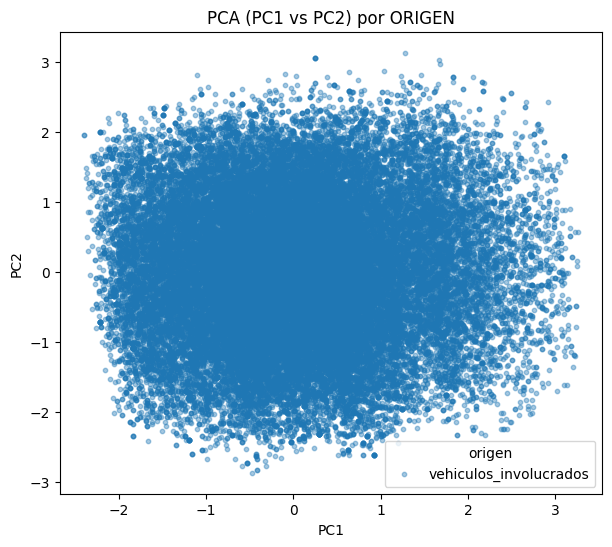

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,6))
for origen, sub in pdf.groupby(pdf["origen"].fillna("Desconocido")):
    ax.scatter(sub["PC1"], sub["PC2"], alpha=0.4, s=10, label=origen)

ax.set_title("PCA (PC1 vs PC2) por ORIGEN")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(title="origen", loc="best")
plt.show()

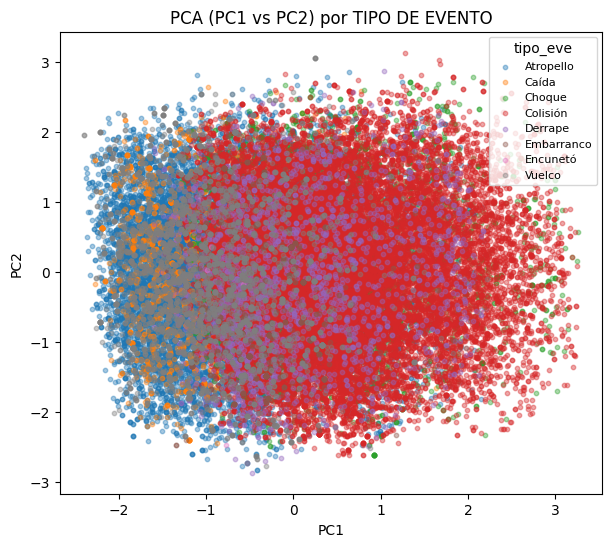

In [30]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,6))
for tipo, sub in pdf.groupby(pdf["tipo_eve"].fillna("Desconocido")):
    ax.scatter(sub["PC1"], sub["PC2"], alpha=0.4, s=10, label=tipo)

ax.set_title("PCA (PC1 vs PC2) por TIPO DE EVENTO")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(title="tipo_eve", loc="best", fontsize=8)
plt.show()

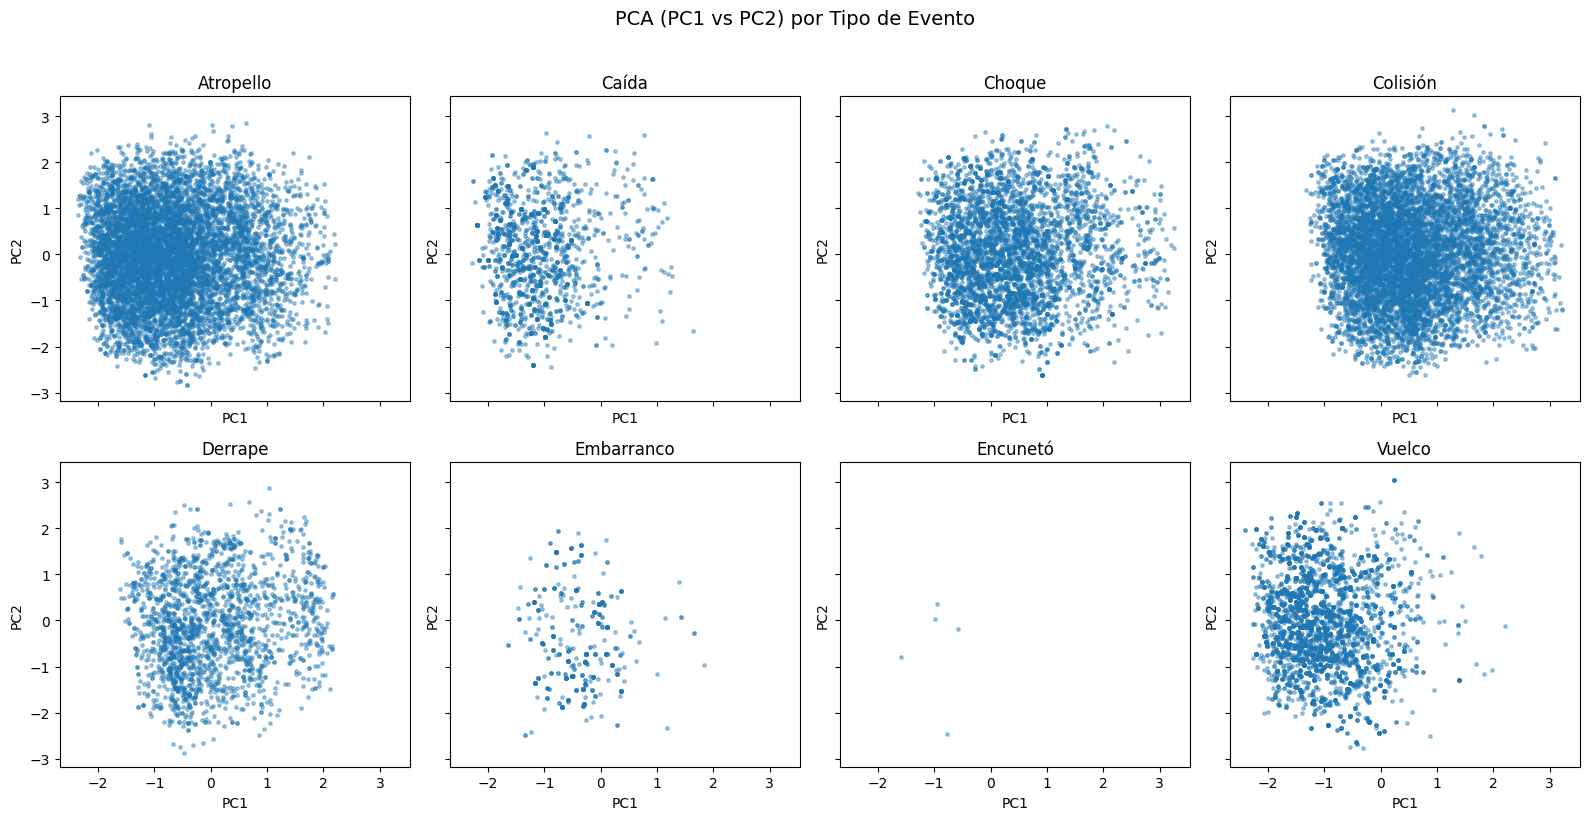

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cats = list(pdf["tipo_eve"].fillna("Desconocido").unique())
cats = sorted(cats)  # opcional

ncols = 4
nrows = int(np.ceil(len(cats) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows), sharex=True, sharey=True)

for ax, cat in zip(axes.ravel(), cats):
    sub = pdf[pdf["tipo_eve"].fillna("Desconocido") == cat]
    # muestrea para que no sature el panel
    if len(sub) > 8000:
        sub = sub.sample(8000, random_state=42)
    ax.scatter(sub["PC1"], sub["PC2"], s=6, alpha=0.4)
    ax.set_title(cat)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

# oculta ejes extra si sobran
for ax in axes.ravel()[len(cats):]:
    ax.axis("off")

fig.suptitle("PCA (PC1 vs PC2) por Tipo de Evento", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

# Inciso 4

In [62]:
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler

# === Features que usaremos en KMeans ===
km_features = [
    "hora_num",
    "num_vehiculos_involucrados",
    "lesionado_ind",
    "fallecido_ind",
    # puedes añadir si quieres:
    # "zona_ocu", "mes_num", "dia_ocu"
]

# Filtra filas con todas las features presentes
km_df = g
for c in km_features:
    km_df = km_df.filter(F.col(c).isNotNull())

print("Filas disponibles:", km_df.count())

# Conserva columnas útiles para interpretar luego (si existen)
interp_cols = [c for c in ["tipo_eve", "origen", "anio", "mes_ocu", "dia_semana"] if c in km_df.columns]

# Assemble -> Scale (estandarizado)
km_assembler = VectorAssembler(inputCols=km_features, outputCol="features", handleInvalid="skip")
km_vec = km_assembler.transform(km_df)

km_scaler = StandardScaler(inputCol="features", outputCol="scaled", withStd=True, withMean=True)
km_scaled = km_scaler.fit(km_vec).transform(km_vec).cache()

km_scaled.select("scaled").show(3, truncate=False)

Filas disponibles: 90391
+--------------------------------------------------+
|scaled                                            |
+--------------------------------------------------+
|[0.23513169483514199,0.8434981210653196,0.0,0.0]  |
|[-0.21798281136540942,-1.1855259804120537,0.0,0.0]|
|[-1.7283644987005808,-1.1855259804120537,0.0,0.0] |
+--------------------------------------------------+
only showing top 3 rows



   k         WSSSE  Silhouette
0  2  90318.080321    0.690395
1  3  50752.323330    0.693445
2  4  23493.676319    0.784560
3  5  18597.506216    0.754859
4  6  13554.117451    0.733087


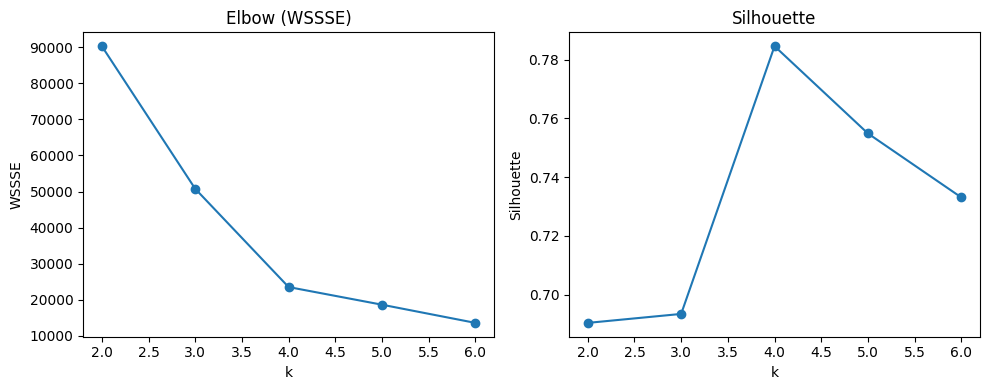

k_final sugerido por Silhouette: 4


In [63]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import pandas as pd
import matplotlib.pyplot as plt

ks = [2, 3, 4, 5, 6]
rows = []

for k in ks:
    km = KMeans(k=k, seed=42, featuresCol="scaled", predictionCol="prediction")
    model = km.fit(km_scaled)
    preds = model.transform(km_scaled)

    wssse = model.summary.trainingCost  # Elbow
    sil = ClusteringEvaluator(featuresCol="scaled", predictionCol="prediction", metricName="silhouette").evaluate(preds)

    rows.append({"k": k, "WSSSE": wssse, "Silhouette": sil})

res = pd.DataFrame(rows)
print(res)

# Graficar codo (WSSSE) y Silhouette
fig, axes = plt.subplots(1,2, figsize=(10,4))
axes[0].plot(res["k"], res["WSSSE"], marker="o")
axes[0].set_title("Elbow (WSSSE)"); axes[0].set_xlabel("k"); axes[0].set_ylabel("WSSSE")

axes[1].plot(res["k"], res["Silhouette"], marker="o")
axes[1].set_title("Silhouette"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
plt.tight_layout(); plt.show()

k_final = int(res.loc[res["Silhouette"].idxmax(), "k"])
print("k_final sugerido por Silhouette:", k_final)

In [64]:
conteo = asignados.groupBy("cluster").count().orderBy("cluster")
conteo.show(truncate=False)

+-------+-----+
|cluster|count|
+-------+-----+
|0      |21792|
|1      |22969|
|2      |31022|
|3      |14608|
+-------+-----+



In [65]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Bandera de noche: 20–23 o 0–5
asignados_desc = asignados.withColumn(
    "is_noche", ((F.col("hora_num") >= 20) | (F.col("hora_num") <= 5)).cast("int")
)

carac = asignados_desc.groupBy("cluster").agg(
    F.count("*").alias("n"),
    F.avg("is_noche").alias("pct_noche"),
    F.avg("fallecido_ind").alias("pct_fallecido"),
    F.avg("lesionado_ind").alias("pct_lesionado"),
    F.avg("num_vehiculos_involucrados").alias("avg_vehiculos"),
    F.avg("hora_num").alias("avg_hora"),
    F.percentile_approx("hora_num", 0.5).alias("mediana_hora"),
)
carac.orderBy("cluster").show(truncate=False)

if "tipo_eve" in asignados_desc.columns:
    dist_tipo = asignados_desc.groupBy("cluster","tipo_eve").count()
    w = Window.partitionBy("cluster").orderBy(F.col("count").desc())
    top_tipo = (dist_tipo
                .withColumn("rn", F.row_number().over(w))
                .filter(F.col("rn")==1)
                .select("cluster","tipo_eve","count")
                .orderBy("cluster"))
    top_tipo.show(truncate=False)

+-------+-----+-------------------+-------------+-------------+-------------+------------------+------------+
|cluster|n    |pct_noche          |pct_fallecido|pct_lesionado|avg_vehiculos|avg_hora          |mediana_hora|
+-------+-----+-------------------+-------------+-------------+-------------+------------------+------------+
|0      |21792|0.3705029368575624 |0.0          |0.0          |2.0          |6.4524596182085165|7           |
|1      |22969|0.36083416779137095|0.0          |0.0          |1.0          |18.165570986982456|18          |
|2      |31022|0.3506866095029334 |0.0          |0.0          |2.0          |18.08584230546064 |18          |
|3      |14608|0.36151423877327493|0.0          |0.0          |1.0          |6.587554764512596 |7           |
+-------+-----+-------------------+-------------+-------------+-------------+------------------+------------+

+-------+---------+-----+
|cluster|tipo_eve |count|
+-------+---------+-----+
|0      |Colisión |17764|
|1      |Atrope

+-------------------+-------------------+-------+
|PC1                |PC2                |cluster|
+-------------------+-------------------+-------+
|0.4301800254331877 |0.7627064572134374 |2      |
|-0.6841563359230883|-0.992430584121138 |3      |
|0.3838447973721464 |-2.0604317174152627|3      |
|0.5974450240311935 |-2.2740319440740873|3      |
|0.6437802520922346 |0.5491062305546125 |2      |
+-------------------+-------------------+-------+
only showing top 5 rows



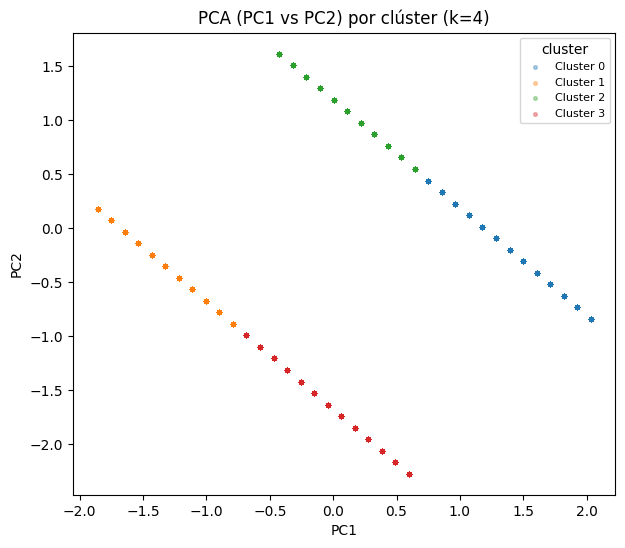

In [66]:
from pyspark.ml.feature import PCA
from pyspark.ml.feature import VectorAssembler, StandardScaler  # ya importados arriba
from pyspark.ml.linalg import Vector
import matplotlib.pyplot as plt

# Usamos las mismas features escaladas (columna 'scaled') para proyectar a 2D
pca = PCA(k=2, inputCol="scaled", outputCol="pcaFeatures")
pca_model = pca.fit(asignados)
pca_df = pca_model.transform(asignados)

# Extraer PC1/PC2 SIN UDF (RDD -> DataFrame) para Spark 3.1
def vec_first_two(v: Vector):
    arr = v.toArray()
    return float(arr[0]), float(arr[1])

pca_plot = (pca_df
    .select("pcaFeatures","cluster")
    .rdd.map(lambda r: (*vec_first_two(r.pcaFeatures), int(r.cluster)))
    .toDF(["PC1","PC2","cluster"])
)

# Muestra rápida y gráfico
pca_plot.show(5, truncate=False)

pdf = pca_plot.toPandas()
# muestrea si hay MUCHAS filas para que se vea mejor
if len(pdf) > 60000:
    pdf = pdf.sample(60000, random_state=42)

fig, ax = plt.subplots(figsize=(7,6))
for cl, sub in pdf.groupby("cluster"):
    ax.scatter(sub["PC1"], sub["PC2"], s=7, alpha=0.35, label=f"Cluster {cl}")
ax.set_title(f"PCA (PC1 vs PC2) por clúster (k={int(k_final)})")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(title="cluster", fontsize=8)
plt.show()

In [67]:
# ¿Cuántos puntos estás graficando?
pca_plot.count()

# ¿Cuántos por clúster?
pca_plot.groupBy("cluster").count().show()

# ¿Cuántos valores únicos de PC1/PC2 por clúster? (si son poquitos → líneas)
from pyspark.sql import functions as F
for c in [0,1,2,3]:
    pca_plot.filter(F.col("cluster")==c).agg(
        F.countDistinct("PC1").alias("uniq_PC1"),
        F.countDistinct("PC2").alias("uniq_PC2")
    ).withColumn("cluster", F.lit(c)).show()

+-------+-----+
|cluster|count|
+-------+-----+
|      0|21792|
|      1|22969|
|      3|14608|
|      2|31022|
+-------+-----+

+--------+--------+-------+
|uniq_PC1|uniq_PC2|cluster|
+--------+--------+-------+
|      13|      13|      0|
+--------+--------+-------+

+--------+--------+-------+
|uniq_PC1|uniq_PC2|cluster|
+--------+--------+-------+
|      11|      11|      1|
+--------+--------+-------+

+--------+--------+-------+
|uniq_PC1|uniq_PC2|cluster|
+--------+--------+-------+
|      11|      11|      2|
+--------+--------+-------+

+--------+--------+-------+
|uniq_PC1|uniq_PC2|cluster|
+--------+--------+-------+
|      13|      13|      3|
+--------+--------+-------+



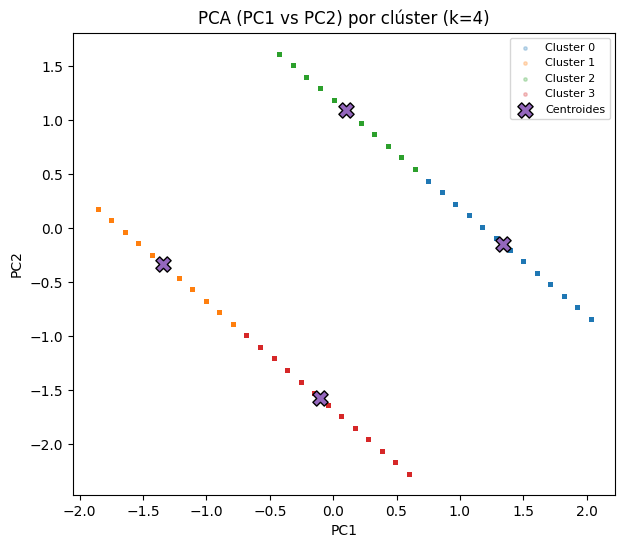

In [68]:
# 1) Muestra de puntos (si hay muchos)
pdf_pts = pca_plot.sample(False, 0.60, seed=42).toPandas()  # 60% de muestra

# 2) Proyectar los centroides al plano PCA
#    Recuerda: entrenaste KMeans sobre 'scaled', así que los centros están en el mismo espacio que 'scaled'.
#    Usa el mismo modelo PCA para llevarlos a (PC1, PC2).
import numpy as np
from pyspark.ml.linalg import Vectors

centers_scaled = model_final.clusterCenters()  # lista de DenseVector en espacio 'scaled'
# Matriz de componentes de PCA (columns = componentes)
pc = np.array(pca_model.pc.toArray())          # shape (num_features, k)
centers_pca = [pc.T.dot(np.array(c)) for c in centers_scaled]  # lista de [PC1, PC2]

import pandas as pd
pdf_ctr = pd.DataFrame(centers_pca, columns=["PC1","PC2"])
pdf_ctr["cluster"] = range(len(centers_pca))

# 3) Graficar
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,6))

# puntos (ligeros)
for cl, sub in pdf_pts.groupby("cluster"):
    ax.scatter(sub["PC1"], sub["PC2"], s=6, alpha=0.25, label=f"Cluster {cl}")

# centroides (marcadores grandes)
ax.scatter(pdf_ctr["PC1"], pdf_ctr["PC2"], s=120, marker="X", edgecolor="k", linewidths=1.0, label="Centroides")

ax.set_title(f"PCA (PC1 vs PC2) por clúster (k={model_final.getK()})")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(fontsize=8)
plt.show()

# Inciso 5

In [69]:
from pyspark.sql import functions as F

# Clave de evento (ajústala si tienes un ID más confiable)
key_cols = [c for c in ["anio","mes_num","dia_ocu","hora_num","depto_ocu","zona_ocu","tipo_eve"] if c in g.columns]

# Agregación por evento: conteos de fallecidos/lesionados
eventos = (
    g.groupBy(*key_cols)
     .agg(
        F.sum(F.col("fallecido_ind")).cast("int").alias("n_fallecidos"),
        F.sum(F.col("lesionado_ind")).cast("int").alias("n_lesionados"),
        # (opcional) conservar otras métricas del evento
        F.first("num_vehiculos_involucrados").alias("num_vehiculos_involucrados")
     )
)

# Regla de severidad
eventos = (
    eventos.withColumn(
        "severidad",
        F.when( (F.col("n_fallecidos")==0) & (F.col("n_lesionados") < 2), "Leve")
         .when( (F.col("n_fallecidos")==1) | ((F.col("n_lesionados")>=2) & (F.col("n_lesionados")<=5)), "Moderado")
         .otherwise("Grave")
    )
)

eventos.select(*key_cols, "n_fallecidos","n_lesionados","severidad").show(10, truncate=False)

+----+-------+-------+--------+--------------+--------+---------+------------+------------+---------+
|anio|mes_num|dia_ocu|hora_num|depto_ocu     |zona_ocu|tipo_eve |n_fallecidos|n_lesionados|severidad|
+----+-------+-------+--------+--------------+--------+---------+------------+------------+---------+
|2016|3      |28     |13      |Guatemala     |18      |Colisión |1           |1           |Moderado |
|2016|2      |29     |20      |Escuintla     |99      |Colisión |0           |1           |Leve     |
|2013|5      |6      |11      |Santa Rosa    |99      |NaN      |0           |0           |Leve     |
|2016|1      |20     |15      |Guatemala     |99      |Vuelco   |0           |4           |Moderado |
|2016|6      |5      |23      |Zacapa        |99      |Colisión |0           |1           |Leve     |
|2013|8      |2      |0       |Escuintla     |99      |NaN      |0           |0           |Leve     |
|2016|7      |16     |8       |Escuintla     |99      |Colisión |0           |2   

+---------+-----+------------------+
|severidad|count|porcentaje        |
+---------+-----+------------------+
|Leve     |62840|70.32701389976945 |
|Moderado |24578|27.50632316404414 |
|Grave    |1936 |2.1666629361864045|
+---------+-----+------------------+



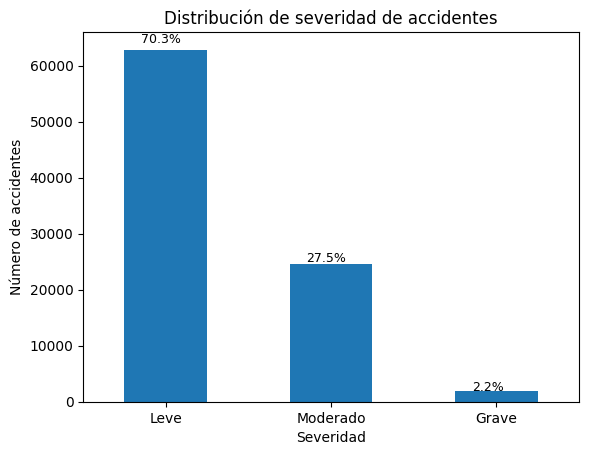

In [70]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

# Conteo y % por categoría
dist = eventos.groupBy("severidad").count()

total = eventos.count()
dist = dist.withColumn("porcentaje", (F.col("count")/F.lit(total)*100))

# Orden lógico de las categorías
orden = F.when(F.col("severidad")=="Leve", 1).when(F.col("severidad")=="Moderado", 2).otherwise(3)
dist = dist.orderBy(orden)

dist.show(truncate=False)

# (Opcional) gráfico simple
pdf_dist = dist.toPandas()
ax = pdf_dist.plot(kind="bar", x="severidad", y="count", legend=False, rot=0)
ax.set_title("Distribución de severidad de accidentes")
ax.set_xlabel("Severidad")
ax.set_ylabel("Número de accidentes")
for i, v in enumerate(pdf_dist["porcentaje"].round(1)):
    ax.text(i-0.15, pdf_dist.loc[i,"count"]*1.02, f"{v}%", fontsize=9)
plt.show()

# Inciso 6

In [71]:
# 70/30 con semilla fija (reproducible)
seed = 42
train, test = eventos.randomSplit([0.7, 0.3], seed=seed)

print("Filas total:", eventos.count())
print("Train:", train.count(), "Test:", test.count())

# Checar distribución de severidad en cada split
from pyspark.sql import functions as F

def dist(df, name):
    total = df.count()
    print(f"\n{name} (n={total})")
    (df.groupBy("severidad")
       .count()
       .withColumn("pct", (F.col("count")/F.lit(total)*100))
       .orderBy("severidad")
       .show(truncate=False))

dist(eventos, "Total")
dist(train, "Train")
dist(test, "Test")

Filas total: 89354


Train: 62826 Test: 26528

Total (n=89354)
+---------+-----+------------------+
|severidad|count|pct               |
+---------+-----+------------------+
|Grave    |1936 |2.1666629361864045|
|Leve     |62840|70.32701389976945 |
|Moderado |24578|27.50632316404414 |
+---------+-----+------------------+


Train (n=62826)


+---------+-----+------------------+
|severidad|count|pct               |
+---------+-----+------------------+
|Grave    |1339 |2.131283226689587 |
|Leve     |44203|70.35781364403273 |
|Moderado |17284|27.510903129277686|
+---------+-----+------------------+


Test (n=26528)
+---------+-----+------------------+
|severidad|count|pct               |
+---------+-----+------------------+
|Grave    |597  |2.2504523522316044|
|Leve     |18637|70.25407117008444 |
|Moderado |7294 |27.495476477683955|
+---------+-----+------------------+



In [72]:
from pyspark.sql import functions as F

seed = 42
train_fracs = {"Leve": 0.7, "Moderado": 0.7, "Grave": 0.7}

# Asegura que severidad sea string consistente
eventos_str = eventos.withColumn("severidad", F.col("severidad").cast("string"))

# Train: sampleBy por clase
train = eventos_str.sampleBy("severidad", fractions=train_fracs, seed=seed)

# Test: left anti join para el resto
test = eventos_str.join(train.select(*eventos_str.columns), on=eventos_str.columns, how="left_anti")

print("Filas total:", eventos_str.count())
print("Train:", train.count(), "Test:", test.count())

# Checar distribución
def dist(df, name):
    total = df.count()
    print(f"\n{name} (n={total})")
    (df.groupBy("severidad")
       .count()
       .withColumn("pct", (F.col("count")/F.lit(total)*100))
       .orderBy("severidad")
       .show(truncate=False))

dist(eventos_str, "Total")
dist(train, "Train")
dist(test, "Test")

Filas total: 89354
Train: 62792 Test: 74456

Total (n=89354)
+---------+-----+------------------+
|severidad|count|pct               |
+---------+-----+------------------+
|Grave    |1936 |2.1666629361864045|
|Leve     |62840|70.32701389976945 |
|Moderado |24578|27.50632316404414 |
+---------+-----+------------------+


Train (n=62792)
+---------+-----+------------------+
|severidad|count|pct               |
+---------+-----+------------------+
|Grave    |1355 |2.1579182061409097|
|Leve     |44168|70.34017072238503 |
|Moderado |17269|27.501911071474073|
+---------+-----+------------------+


Test (n=74456)
+---------+-----+------------------+
|severidad|count|pct               |
+---------+-----+------------------+
|Grave    |1790 |2.404104437520146 |
|Leve     |51685|69.41683678951327 |
|Moderado |20981|28.179058772966588|
+---------+-----+------------------+

